In [ ]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
from torch.testing import assert_close

torch.manual_seed(0)

device = torch.device('cuda') if torch.cuda.is_available() else (torch.device("mps") if torch.mps.is_available() else torch.device("cpu"))

In [ ]:
def layernorm_forward_torch(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    
    rstd = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mean) * rstd
    
    # 4. Применяем scale (weight) и shift (bias)
    output = x_hat * weight + bias
    
    return output


def layernorm_backward_torch(x, weight, bias, dy, eps=1e-5):
    x_ref = x.detach().clone().requires_grad_(True)
    weight_ref = weight.detach().clone().requires_grad_(True)
    bias_ref = bias.detach().clone().requires_grad_(True)

    y_ref = layernorm_forward_torch(x_ref, weight_ref, bias_ref, eps)
    y_ref.backward(dy)

    return x_ref.grad, weight_ref.grad, bias_ref.grad


In [ ]:
def next_power_of_2(value):
    if value <= 0:
        raise ValueError("value must be positive")
    return 1 << (value - 1).bit_length()

@triton.autotune(
    configs=[
        triton.Config({}, num_warps=1),
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
    ],
    key=["N", "BLOCK_N"],
)
@triton.jit
def _layernorm_forward_kernel(x, weight, bias, y, mean, rstd, N: tl.constexpr, eps: tl.constexpr, BLOCK_N: tl.constexpr):
    row_id = tl.program_id(0)
    cols = tl.arange(0, BLOCK_N)
    in_bounds = cols < N

    row_start = row_id * N
    x_row = tl.load(x + row_start + cols, mask=in_bounds, other=0.0).to(tl.float32)
    gamma = tl.load(weight + cols, mask=in_bounds, other=0.0).to(tl.float32)
    beta = tl.load(bias + cols, mask=in_bounds, other=0.0).to(tl.float32)

    mean_val = tl.sum(x_row, axis=0) / N
    centered = tl.where(in_bounds, x_row - mean_val, 0.0)
    variance = tl.sum(centered * centered, axis=0) / N
    inv_std = tl.rsqrt(variance + eps)

    normalized = centered * inv_std
    y_row = normalized * gamma + beta

    tl.store(y + row_start + cols, y_row, mask=in_bounds)
    tl.store(mean + row_id, mean_val)
    tl.store(rstd + row_id, inv_std)


@triton.autotune(
    configs=[
        triton.Config({}, num_warps=1),
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
    ],
    key=["N", "BLOCK_N"],
    reset_to_zero=["dweight", "dbias"],
)
@triton.jit
def _layernorm_backward_kernel(dy, x, weight, mean, rstd, dx, dweight, dbias, N: tl.constexpr, BLOCK_N: tl.constexpr):
    row_id = tl.program_id(0)
    cols = tl.arange(0, BLOCK_N)
    in_bounds = cols < N

    row_start = row_id * N
    x_row = tl.load(x + row_start + cols, mask=in_bounds, other=0.0).to(tl.float32)
    dy_row = tl.load(dy + row_start + cols, mask=in_bounds, other=0.0).to(tl.float32)
    gamma = tl.load(weight + cols, mask=in_bounds, other=0.0).to(tl.float32)

    mean_val = tl.load(mean + row_id).to(tl.float32)
    inv_std = tl.load(rstd + row_id).to(tl.float32)

    x_hat = (x_row - mean_val) * inv_std
    grad_norm = dy_row * gamma

    inv_n = 1.0 / N
    grad_sum = tl.sum(grad_norm, axis=0)
    grad_xhat_sum = tl.sum(grad_norm * x_hat, axis=0)

    dx_row = (grad_norm - grad_sum * inv_n - x_hat * grad_xhat_sum * inv_n) * inv_std

    tl.store(dx + row_start + cols, dx_row, mask=in_bounds)
    tl.atomic_add(dweight + cols, dy_row * x_hat, mask=in_bounds)
    tl.atomic_add(dbias + cols, dy_row, mask=in_bounds)


In [7]:
def layernorm_forward_triton(x, weight, bias, eps=1e-5):
    x_c = x.contiguous()
    weight_c = weight.contiguous()
    bias_c = bias.contiguous()

    original_shape = x_c.shape
    feature_count = original_shape[-1]
    row_count = x_c.numel() // feature_count

    assert x_c.is_cuda and weight_c.is_cuda and bias_c.is_cuda
    assert weight_c.numel() == feature_count
    assert bias_c.numel() == feature_count

    x_2d = x_c.reshape(row_count, feature_count)
    y_2d = torch.empty_like(x_2d)
    mean = torch.empty((row_count,), device=x_c.device, dtype=torch.float32)
    rstd = torch.empty((row_count,), device=x_c.device, dtype=torch.float32)

    block_n = next_power_of_2(feature_count)

    _layernorm_forward_kernel[(row_count,)](
        x_2d,
        weight_c,
        bias_c,
        y_2d,
        mean,
        rstd,
        N=feature_count,
        eps=eps,
        BLOCK_N=block_n,
    )

    return y_2d.reshape(original_shape), mean, rstd


def layernorm_backward_triton(dy, x, weight, mean, rstd):
    dy_c = dy.contiguous()
    x_c = x.contiguous()
    weight_c = weight.contiguous()

    original_shape = x_c.shape
    feature_count = original_shape[-1]
    row_count = x_c.numel() // feature_count

    assert dy_c.is_cuda and x_c.is_cuda and weight_c.is_cuda
    assert dy_c.shape == original_shape

    dy_2d = dy_c.reshape(row_count, feature_count)
    x_2d = x_c.reshape(row_count, feature_count)

    dx_2d = torch.empty_like(x_2d)
    dweight = torch.zeros((feature_count,), device=x_c.device, dtype=torch.float32)
    dbias = torch.zeros((feature_count,), device=x_c.device, dtype=torch.float32)

    block_n = next_power_of_2(feature_count)

    _layernorm_backward_kernel[(row_count,)](
        dy_2d,
        x_2d,
        weight_c,
        mean,
        rstd,
        dx_2d,
        dweight,
        dbias,
        N=feature_count,
        BLOCK_N=block_n,
    )

    return dx_2d.reshape(original_shape), dweight, dbias


In [8]:
class TritonLayerNormFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias, eps=1e-5):
        y, mean, rstd = layernorm_forward_triton(x, weight, bias, eps)
        x_saved = x.contiguous()
        weight_saved = weight.contiguous()
        ctx.save_for_backward(x_saved, weight_saved, mean, rstd)
        return y

    @staticmethod
    def backward(ctx, dy):
        x_saved, weight_saved, mean, rstd = ctx.saved_tensors
        dx, dweight, dbias = layernorm_backward_triton(dy, x_saved, weight_saved, mean, rstd)
        return dx, dweight.to(weight_saved.dtype), dbias.to(weight_saved.dtype), None


def layernorm_triton(x, weight, bias, eps=1e-5):
    return TritonLayerNormFunction.apply(x, weight, bias, eps)


In [9]:
eps = 1e-5
check_shapes = ((16, 128), (128, 512), (512, 1024), (1024, 2048))

for M, N in check_shapes:
    x = torch.randn(M, N, device=device, dtype=torch.float32)
    weight = torch.randn(N, device=device, dtype=torch.float32)
    bias = torch.randn(N, device=device, dtype=torch.float32)
    dy = torch.randn_like(x)

    y_triton, mean, rstd = layernorm_forward_triton(x, weight, bias, eps)
    y_torch = layernorm_forward_torch(x, weight, bias, eps)

    dx_triton, dw_triton, db_triton = layernorm_backward_triton(dy, x, weight, mean, rstd)
    dx_torch, dw_torch, db_torch = layernorm_backward_torch(x, weight, bias, dy, eps)

    assert_close(y_triton, y_torch, rtol=1e-4, atol=1e-4)
    assert_close(dx_triton, dx_torch, rtol=1e-3, atol=1e-3)
    assert_close(dw_triton, dw_torch, rtol=1e-3, atol=1e-3)
    assert_close(db_triton, db_torch, rtol=1e-3, atol=1e-3)

print("all checks passed")


all checks passed


In [10]:
M, N = 512, 1024
eps = 1e-5

x1 = torch.randn(M, N, device=device, dtype=torch.float32, requires_grad=True)
w1 = torch.randn(N, device=device, dtype=torch.float32, requires_grad=True)
b1 = torch.randn(N, device=device, dtype=torch.float32, requires_grad=True)

x2 = x1.detach().clone().requires_grad_(True)
w2 = w1.detach().clone().requires_grad_(True)
b2 = b1.detach().clone().requires_grad_(True)

dy = torch.randn_like(x1)

y1 = layernorm_triton(x1, w1, b1, eps)
y2 = torch.nn.functional.layer_norm(x2, (N,), w2, b2, eps)

(y1 * dy).sum().backward()
(y2 * dy).sum().backward()

assert_close(y1, y2, rtol=1e-4, atol=1e-4)
assert_close(x1.grad, x2.grad, rtol=1e-3, atol=1e-3)
assert_close(w1.grad, w2.grad, rtol=1e-3, atol=1e-3)
assert_close(b1.grad, b2.grad, rtol=1e-3, atol=1e-3)

print("autograd check passed")


autograd check passed


In [11]:
def benchmark_case(M, N, eps=1e-5):
    x = torch.randn(M, N, device=device, dtype=torch.float32)
    weight = torch.randn(N, device=device, dtype=torch.float32)
    bias = torch.randn(N, device=device, dtype=torch.float32)
    dy = torch.randn_like(x)

    y, mean, rstd = layernorm_forward_triton(x, weight, bias, eps)
    layernorm_backward_triton(dy, x, weight, mean, rstd)

    x_ref = x.detach().clone().requires_grad_(True)
    w_ref = weight.detach().clone().requires_grad_(True)
    b_ref = bias.detach().clone().requires_grad_(True)
    y_ref = torch.nn.functional.layer_norm(x_ref, (N,), w_ref, b_ref, eps)
    y_ref.backward(dy, retain_graph=True)

    torch.cuda.synchronize()

    triton_fwd_ms = triton.testing.do_bench(lambda: layernorm_forward_triton(x, weight, bias, eps)[0])
    torch_fwd_ms = triton.testing.do_bench(lambda: torch.nn.functional.layer_norm(x, (N,), weight, bias, eps))

    y, mean, rstd = layernorm_forward_triton(x, weight, bias, eps)

    triton_bwd_ms = triton.testing.do_bench(lambda: layernorm_backward_triton(dy, x, weight, mean, rstd))

    def clear_reference_grads():
        x_ref.grad = None
        w_ref.grad = None
        b_ref.grad = None

    def torch_bwd():
        clear_reference_grads()
        y_ref.backward(dy, retain_graph=True)

    torch_bwd_ms = triton.testing.do_bench(torch_bwd)

    bytes_per_value = 4
    fwd_bytes = (4 * M * N + 2 * M) * bytes_per_value
    bwd_bytes = (6 * M * N + 2 * M + 2 * N) * bytes_per_value

    return {
        "M": M,
        "N": N,
        "triton_fwd_ms": triton_fwd_ms,
        "torch_fwd_ms": torch_fwd_ms,
        "triton_bwd_ms": triton_bwd_ms,
        "torch_bwd_ms": torch_bwd_ms,
        "triton_fwd_gbps": fwd_bytes / triton_fwd_ms / 1e6,
        "torch_fwd_gbps": fwd_bytes / torch_fwd_ms / 1e6,
        "triton_bwd_gbps": bwd_bytes / triton_bwd_ms / 1e6,
        "torch_bwd_gbps": bwd_bytes / torch_bwd_ms / 1e6,
        "fwd_speedup": torch_fwd_ms / triton_fwd_ms,
        "bwd_speedup": torch_bwd_ms / triton_bwd_ms,
    }


In [12]:
benchmark_ns = (256, 512, 1024, 2048, 4096)
results = [benchmark_case(4096, N) for N in benchmark_ns]

for r in results:
    print(
        f"M={r['M']} N={r['N']} | "
        f"fwd Triton {r['triton_fwd_ms']:.4f} ms, Torch {r['torch_fwd_ms']:.4f} ms, speedup {r['fwd_speedup']:.2f} | "
        f"bwd Triton {r['triton_bwd_ms']:.4f} ms, Torch {r['torch_bwd_ms']:.4f} ms, speedup {r['bwd_speedup']:.2f}"
    )


M=4096 N=256 | fwd Triton 0.0315 ms, Torch 0.0299 ms, speedup 0.95 | bwd Triton 0.0873 ms, Torch 0.0765 ms, speedup 0.88
M=4096 N=512 | fwd Triton 0.0491 ms, Torch 0.0541 ms, speedup 1.10 | bwd Triton 0.1322 ms, Torch 0.1359 ms, speedup 1.03
M=4096 N=1024 | fwd Triton 0.0951 ms, Torch 0.1243 ms, speedup 1.31 | bwd Triton 0.4152 ms, Torch 0.3195 ms, speedup 0.77
M=4096 N=2048 | fwd Triton 0.1672 ms, Torch 0.2630 ms, speedup 1.57 | bwd Triton 0.5465 ms, Torch 0.6100 ms, speedup 1.12
M=4096 N=4096 | fwd Triton 0.3469 ms, Torch 0.5312 ms, speedup 1.53 | bwd Triton 1.0353 ms, Torch 1.2258 ms, speedup 1.18


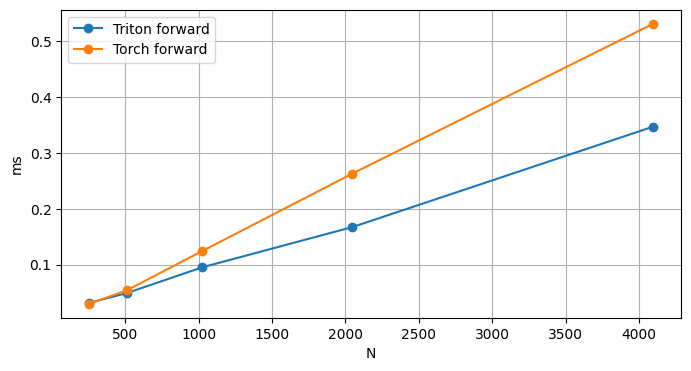

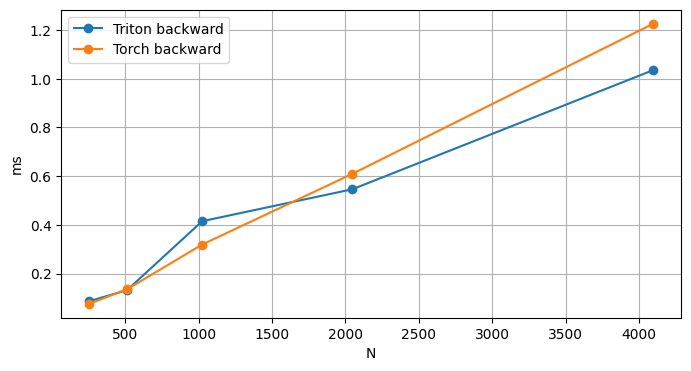

In [13]:
Ns = tuple(r["N"] for r in results)

plt.figure(figsize=(8, 4))
plt.plot(Ns, [r["triton_fwd_ms"] for r in results], marker="o", label="Triton forward")
plt.plot(Ns, [r["torch_fwd_ms"] for r in results], marker="o", label="Torch forward")
plt.xlabel("N")
plt.ylabel("ms")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(Ns, [r["triton_bwd_ms"] for r in results], marker="o", label="Triton backward")
plt.plot(Ns, [r["torch_bwd_ms"] for r in results], marker="o", label="Torch backward")
plt.xlabel("N")
plt.ylabel("ms")
plt.grid(True)
plt.legend()
plt.show()
